In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/nigeria.csv",low_memory=False
)
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [2]:
# Add new columns
df["Country"]="Nigeria"
df["Date"]= pd.to_datetime(df["YEAR"]* 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month


In [3]:
df= df.replace(-999, np.nan)
df.duplicated().sum()

np.int64(0)

No duplicated row was found

In [4]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

No missing value was found

In [5]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


The dataset represents a warm, humid tropical climate with stable temperature and pressure conditions. Rainfall is highly variable and skewed, with occasional extreme precipitation events, while wind speed remains consistently low. The data shows clear seasonal structure but no strong long-term instability in atmospheric variables.

In [6]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore, nan_policy='omit')

outliers = (np.abs(z_scores) > 3)

outlier_count = outliers.sum()

outlier_count

T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
WS2M_MAX        10
dtype: int64

In [7]:
# make copy
df_cleaned = df.copy()

# columns to clean (adjust if needed)
cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE",
        "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]

# --- OUTLIER HANDLING: 1% - 99% quantile clipping ---
for col in cols:
    lower = df_cleaned[col].quantile(0.01)
    upper = df_cleaned[col].quantile(0.99)

    df_cleaned[col] = df_cleaned[col].clip(lower=lower, upper=upper)

# --- OPTIONAL (highly recommended): transform rainfall ---
df_cleaned["PRECTOTCORR"] = np.log1p(df_cleaned["PRECTOTCORR"])

# save cleaned dataset
df_cleaned.to_csv("../data/nigeria_clean.csv", index=False)

print("Cleaning completed and file saved.")

Cleaning completed and file saved.


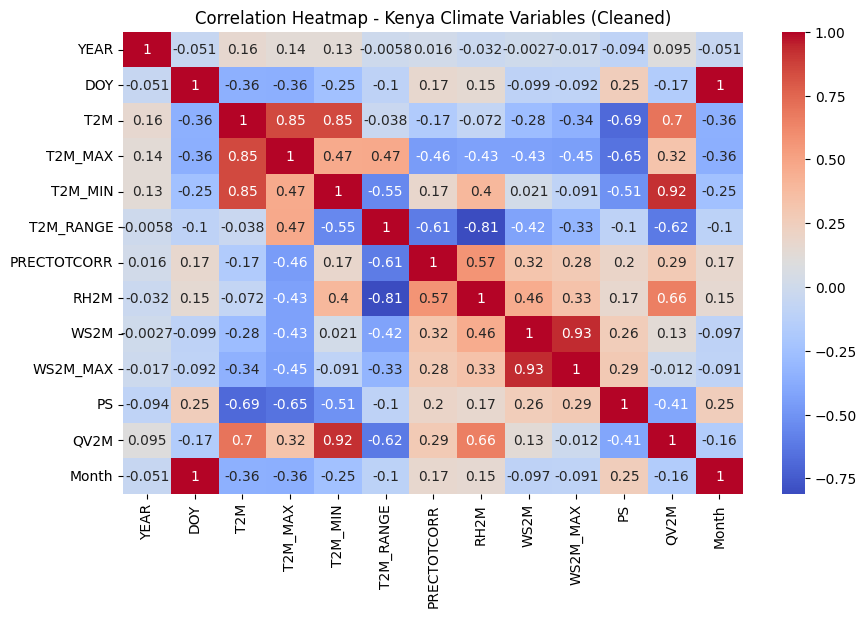

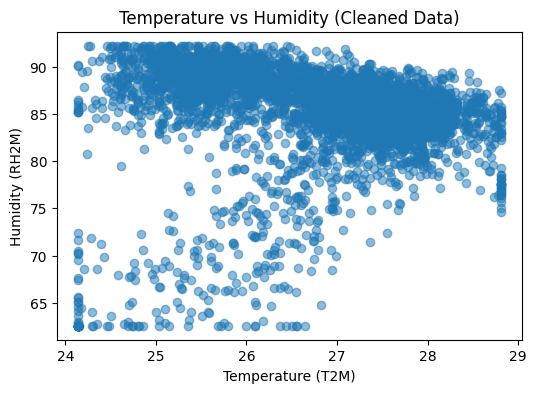

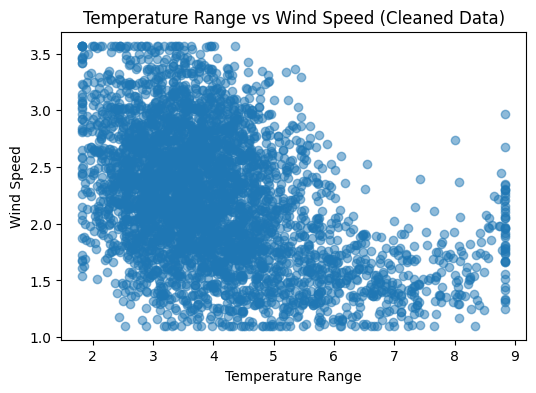

In [8]:


# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap (CLEANED DATA)
plt.figure(figsize=(10,6))
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Kenya Climate Variables (Cleaned)")
plt.show()

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df_cleaned["T2M"], df_cleaned["RH2M"], alpha=0.5)
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("Temperature vs Humidity (Cleaned Data)")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df_cleaned["T2M_RANGE"], df_cleaned["WS2M"], alpha=0.5)
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("Temperature Range vs Wind Speed (Cleaned Data)")
plt.show()

In [9]:
df_cleaned["PRECTOTCORR"].describe()

count    4108.000000
mean        1.146307
std         0.931768
min         0.000000
25%         0.285179
50%         1.043804
75%         1.824549
max         3.525913
Name: PRECTOTCORR, dtype: float64

The cleaned PRECTOTCORR (rainfall) data shows a generally low to moderate level of precipitation, with an average of about 1.15 and a median of 1.04, indicating that most days experience light rainfall. The distribution is slightly right-skewed, as seen from the higher 75th percentile (1.82) compared to the median, meaning occasional days receive more rainfall than typical conditions. The minimum value of 0 confirms that there are completely dry days, while the maximum of 3.53 shows that extreme rainfall values have been reduced after cleaning.

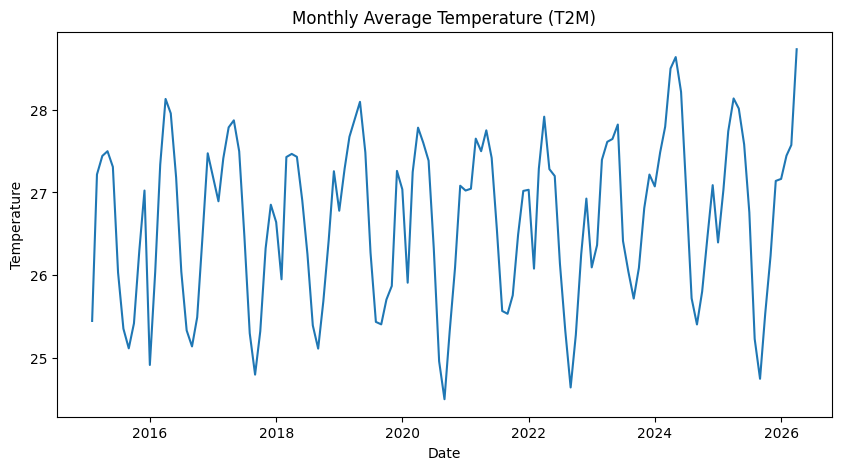

In [10]:
#T2m
import matplotlib.pyplot as plt

# ensure datetime
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"])

# set index for resampling
df_ts = df_cleaned.set_index("Date")

# monthly average temperature
monthly_temp = df_ts["T2M"].resample("ME").mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp)
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

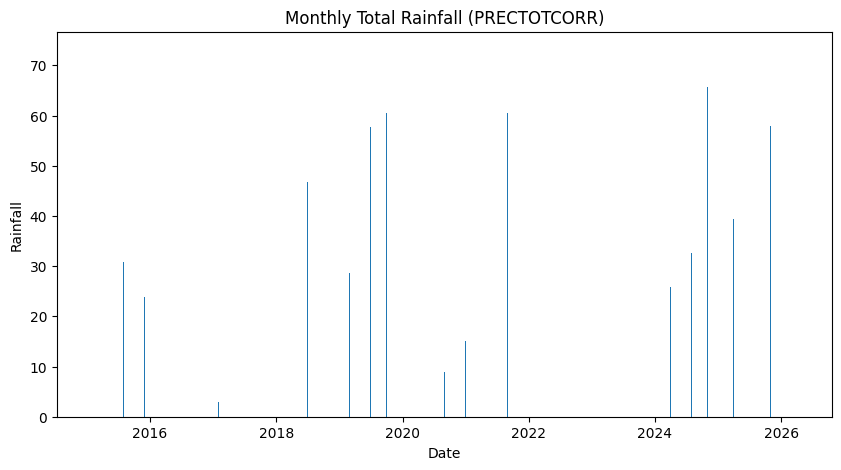

In [11]:
# Rain fall
monthly_rain = df_ts["PRECTOTCORR"].resample("ME").sum()

plt.figure(figsize=(10,5))
plt.bar(monthly_rain.index, monthly_rain)
plt.title("Monthly Total Rainfall (PRECTOTCORR)")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.show()

In [12]:
# cleaned correlation
corr = df_cleaned.corr(numeric_only=True)

# unstack and sort correlations
corr_pairs = corr.unstack().sort_values(ascending=False)

# remove self-correlation
corr_pairs = corr_pairs[corr_pairs < 1]

print("Top Correlations:")
print(corr_pairs.head(10))

Top Correlations:
DOY       Month       0.996557
Month     DOY         0.996557
WS2M      WS2M_MAX    0.930013
WS2M_MAX  WS2M        0.930013
T2M_MIN   QV2M        0.921880
QV2M      T2M_MIN     0.921880
T2M_MAX   T2M         0.849193
T2M       T2M_MAX     0.849193
T2M_MIN   T2M         0.845622
T2M       T2M_MIN     0.845622
dtype: float64


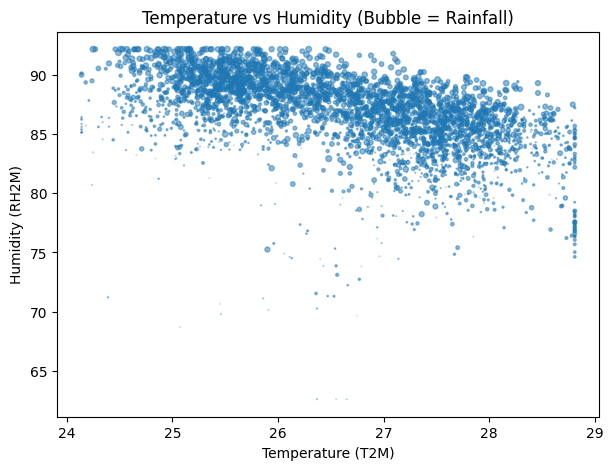

In [13]:
# bubble
plt.figure(figsize=(7,5))

plt.scatter(
    df_cleaned["T2M"],
    df_cleaned["RH2M"],
    s=df_cleaned["PRECTOTCORR"] * 5,
    alpha=0.5
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()